# Single perturbations: genome-scale CRISPRi Perturb-seq (Replogle)

This tutorial covers the simplest design: one perturbation per cell and no experimental
conditions. It walks through a complete SHERLOCK analysis of the K562 genome-scale CRISPRi
Perturb-seq screen from Replogle et al. (2022). It reproduces the single-perturbation analyses
of the manuscript's Figure 1:

1. **Load and prepare** a perturbation dataset.
2. **Compute ground-truth average treatment effects (ATEs)** from the data.
3. **Train** SHERLOCK (or load a pretrained checkpoint).
4. **Evaluate** the model: latent embedding, reconstruction and counterfactual ATE accuracy.
5. **Group perturbations** using the learned perturbation covariance and compare the groups
   with annotated pathways.
6. **Inspect the sparse gates** that link each perturbation to latent factors.
7. **Estimate downstream effects** of each perturbation and test which target genes are significant.
8. **Run pathway-level enrichment** of the inferred downstream targets.

**What SHERLOCK models.** Each cell has a baseline latent state $z^0$, inferred from control
(non-targeting) cells. A perturbation $p$ shifts that state by a sparse, gated vector
$\Delta_p = W_p \odot A_p$. $A = C_P\,\rho$ is the perturbation embedding, correlated across
perturbations through a low-rank covariance $\Sigma_P$, and $W$ is a sparse gate. A negative
binomial decoder maps the perturbed latent state back to counts. Because the shift acts on an
inferred baseline, the same machinery supports counterfactual questions such as "what would
this control cell look like under perturbation $p$?"

## 1. Setup

In [1]:
import os

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment

import sherlock as slk   # pip install sherlock-perturb

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


### Configuration keys

SHERLOCK reads cell annotations from a few standardized `.obs` columns. The defaults are:

| key | default | meaning |
|---|---|---|
| `pert_key` | `pert` | column holding each cell's perturbation label |
| `ntc_label` | `NTC` | label used for control (non-targeting) cells |
| `treatment_key` | `treatment` | column holding the experimental condition |
| `untreated_label` | `untreated` | label for the reference condition |

Change these globally with `slk.configs.set_config(...)`. However, the simplest approach is to
leave the defaults and map your own columns onto them with `slk.pp.slk_prepare_data` (see
below).

In [2]:
slk.configs.reset_config()
slk.configs.show()

ntc_label       = NTC
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


## 2. Load the data

`slk.datasets.replogle()` loads a working subset of the screen: 118,641 cells, 1,185 genes and
681 targeted genes plus non-targeting controls. It also maps the dataset's own columns onto
SHERLOCK's standard keys. On first use the file (about 570 MB) is downloaded to
`~/.cache/sherlock`; pass `path=` to read a local copy instead.

> **Using your own data.** Start from an AnnData with raw counts in `.X`, then run:
> ```python
> data = sc.read_h5ad("my_screen.h5ad")
> slk.pp.slk_prepare_data(
>     data,
>     pert_key="guide_target",         # your perturbation column
>     ntc_label="non-targeting",       # your control label
>     treatment_key=None,              # or your condition column, e.g. "drug"
>     untreated_label=None,            # e.g. "DMSO" when treatment_key is set
>     inplace=True,
> )
> ```

In [3]:
data = slk.datasets.replogle()

P_KEY = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

print(f"Cells: {data.n_obs:,}   Genes: {data.n_vars:,}   "
      f"Perturbation labels: {data.obs[P_KEY].nunique()} (incl. {NTC})")
print(f"Control cells: {(data.obs[P_KEY] == NTC).sum():,}")

Cells: 118,641   Genes: 1,185   Perturbation labels: 682 (incl. NTC)
Control cells: 2,000


### Pathway annotations

Replogle et al. annotated eight non-overlapping complexes and pathways covering 335 of the
targeted genes. We use them only for **evaluation**. SHERLOCK never sees them during training.

In [4]:
pathways = data.uns['pathways']

pathway_genes = [g for genes in pathways.values() for g in genes if g != 'LSM5']
gene_to_pathway = {g: pw for pw, genes in pathways.items() for g in genes if g != 'LSM5'}
pathway_df = pd.DataFrame.from_dict(gene_to_pathway, orient='index', columns=['pathway'])
pathway_df.index.name = 'gene'

assert pathway_df.index.is_unique, "a gene appears in more than one pathway"
pathway_df['pathway'].value_counts().rename('n_genes').to_frame()

,n_genes
pathway,
S40_RIBOSOMAL_UNIT,97
S60_RIBOSOMAL_UNIT,53
S39_RIBOSOMAL_UNIT,43
MT_PROTEIN_TRANSLOCATION,40
SPLICEOSOME,33
MEDIATOR_COMPLEX,26
NUCLEOTIDE_EXCISION_REPAIR,23
EXOSOME,20


## 3. Ground-truth average treatment effects

For each perturbation, the observed ATE is the difference in mean normalized expression between
its cells and the control cells. It is stored in `data.uns['treat_effect']`, and it's the
reference we compare SHERLOCK's counterfactual predictions against. The trainer also uses it to
track validation performance.

In [5]:
slk.pp.treat_effect(
    data,
    label_col=P_KEY,
    control_label=NTC,
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)

## 4. Train SHERLOCK

`slk.tl.run(data, model="vae", ...)` trains SHERLOCK. The settings below are the ones used for
the manuscript's Replogle benchmark (`benchmarking.ipynb`):

| argument | value | role |
|---|---|---|
| `latent_dim` | 16 | size of the latent cell state |
| `l0_lambda` | 0.1 | sparsity penalty on the perturbation-to-latent gates $W$ |
| `n_epochs_l0_warmup` | 300 | epochs over which the sparsity penalty is ramped in |
| `ce_lambda` | 20 | weight of the auxiliary perturbation classifier |
| `num_epochs` / `patience` | 500 / 20 | maximum epochs and early-stopping patience (in validation rounds) |
| `validate_every` | 50 | how often the counterfactual ATE is checked on validation |

Training takes about 15 minutes on a GPU. If a saved checkpoint exists, we load it instead; the
checkpoint used here is the best of the five benchmark runs from the manuscript. Set
`RETRAIN = True` to train from scratch. With `debug=True`, the training curve (validation
ATE and gate activity) is plotted when training finishes.

> Always save with `slk.tl.save_results`. The checkpoint must include the Pyro parameter store
> (for example the covariance scale `sigma_fac`), not just the network weights, or evaluation
> will fail after a reload.

In [6]:
CHECKPOINT = "../../results/tutorials/replogle_sherlock.pth"
RETRAIN    = False

if not RETRAIN and os.path.exists(CHECKPOINT):
    print(f"Loading pretrained model from {CHECKPOINT}")
    model = slk.tl.load_results(CHECKPOINT).to(DEVICE)
else:
    results = slk.tl.run(
        data,
        model="vae",
        latent_dim=16,
        batch_size=4096,
        num_epochs=500,
        validate_every=50,
        patience=20,
        l0_lambda=1e-1,
        n_epochs_l0_warmup=300,
        ce_lambda=20.,
        seed=0,
        device=DEVICE,
        debug=True,
    )
    slk.tl.save_results(results, CHECKPOINT)
    model = results['model']
    print(f"Saved model to {CHECKPOINT}")

Loading pretrained model from ../../results/tutorials/replogle_sherlock.pth


## 5. Evaluate the model

`slk.tl.eval` runs inference on every cell and writes the results into the AnnData:

- `data.obsm['z']`: the perturbed latent state of each cell.
- `data.layers['x_pred']`: the reconstructed expression.
- `data.uns['results']`: a dictionary of model summaries, including
  - `rho_corr` / `rho_perts`: correlations between the learned perturbation effects (from $\Sigma_P$ and the gates),
  - `z_corr` / `z_perts`: correlations between the per-perturbation mean latent states,
  - `W`: the gate matrix (perturbations × latent factors),
  - `counterfactual_effect_size`: the per-perturbation, per-gene downstream effect.

In [7]:
slk.tl.eval(model, data, obsm_key='z', uns_key='results', device=DEVICE)
res = data.uns['results']
print("Stored results:", list(res.keys()))

Stored results: ['z_corr', 'z_perts', 'z_embed', 'rho_corr', 'rho_perts', 'rho_embed', 'acc', 'z_rho_corr', 'W', 'synergy_enabled', 'synergy_rank', 'counterfactual_effect_size', 'condition_perturbation_interaction', 'conditions']


### Reconstruction

As a sanity check, we compare observed and reconstructed expression for a random sample of
perturbed cells.

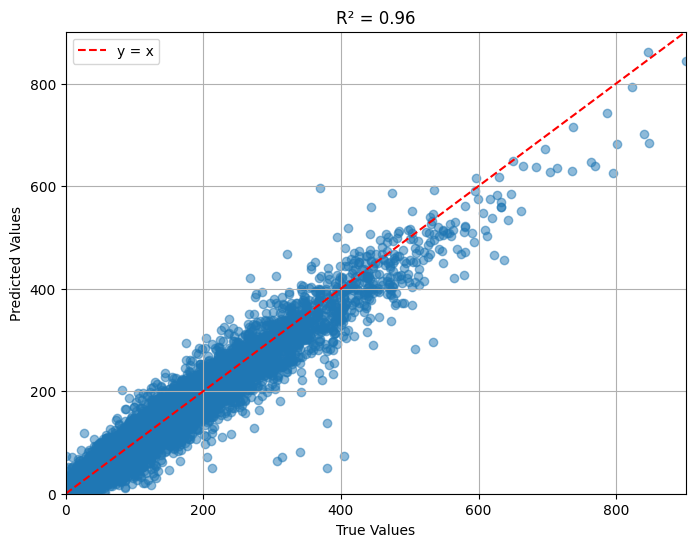

In [8]:
slk.pl.plot_r2(data)

### Counterfactual ATE

This is the main quantitative check (the "ATE" column of Fig. 1g). For every perturbation,
SHERLOCK:
1. **abducts** baseline latent states from the control population,
2. **intervenes** by adding that perturbation's shift $\Delta_p$, and
3. **decodes** the result, comparing it with decoding the unshifted baseline.

The predicted effect matrix (perturbations × genes) is then correlated with the observed ATEs.

Counterfactual ATE Pearson r (all perturbations x genes): 0.751


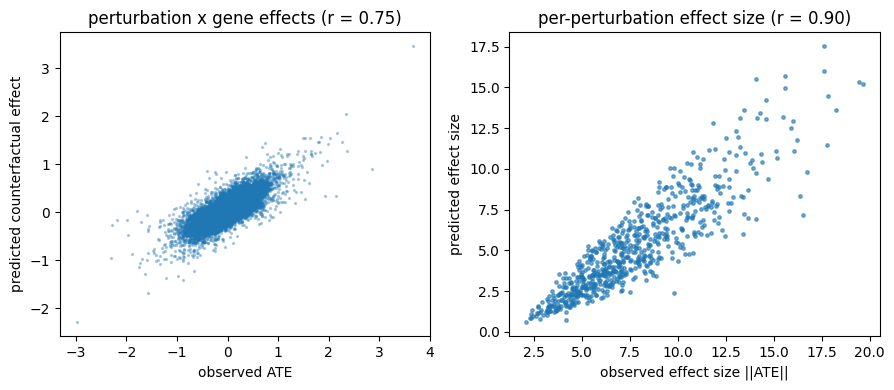

In [9]:
cf = model.predict_counterfactual_effects(
    data, observed_effect=data.uns['treat_effect'], device=DEVICE,
)
pred_df, obs_df = cf['predicted_df'], cf['observed_df']
print(f"Counterfactual ATE Pearson r (all perturbations x genes): {cf['corr']:.3f}")

# Effect magnitude per perturbation: does the model rank strong and weak perturbations correctly?
pred_norm = np.linalg.norm(pred_df.values, axis=1)
obs_norm  = np.linalg.norm(obs_df.values, axis=1)
r_size = np.corrcoef(pred_norm, obs_norm)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
rng = np.random.default_rng(0)
idx = rng.choice(pred_df.size, size=min(50_000, pred_df.size), replace=False)
axes[0].scatter(obs_df.values.ravel()[idx], pred_df.values.ravel()[idx], s=2, alpha=0.3)
axes[0].set(xlabel='observed ATE', ylabel='predicted counterfactual effect',
            title=f"perturbation x gene effects (r = {cf['corr']:.2f})")
axes[1].scatter(obs_norm, pred_norm, s=6, alpha=0.6)
axes[1].set(xlabel='observed effect size ||ATE||', ylabel='predicted effect size',
            title=f"per-perturbation effect size (r = {r_size:.2f})")
plt.tight_layout()
plt.show()

## 6. Perturbation structure

### Latent space

A UMAP of the latent states of perturbed cells, colored by annotated pathway, corresponds to
Fig. 1d (right panel). Cells whose perturbations act on the same complex should sit together.

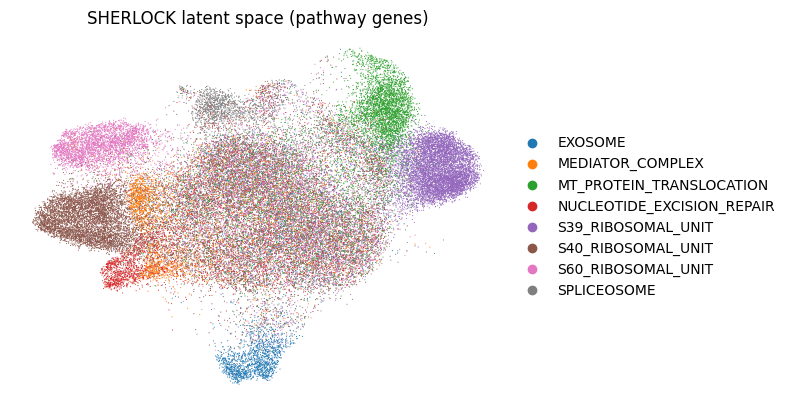

In [10]:
sub = data[data.obs[P_KEY] != NTC].copy()
sub.obs['pathway'] = sub.obs[P_KEY].map(gene_to_pathway).astype('category')
sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

sc.pl.umap(sub[sub.obs['pathway'].notna()], color='pathway', frameon=False,
           title='SHERLOCK latent space (pathway genes)')

### Learned perturbation correlations

`rho_corr` is the correlation between the learned perturbation effects. Restricted to the
annotated genes and ordered by hierarchical clustering, it shows block structure that follows
the pathways (Fig. 1e).

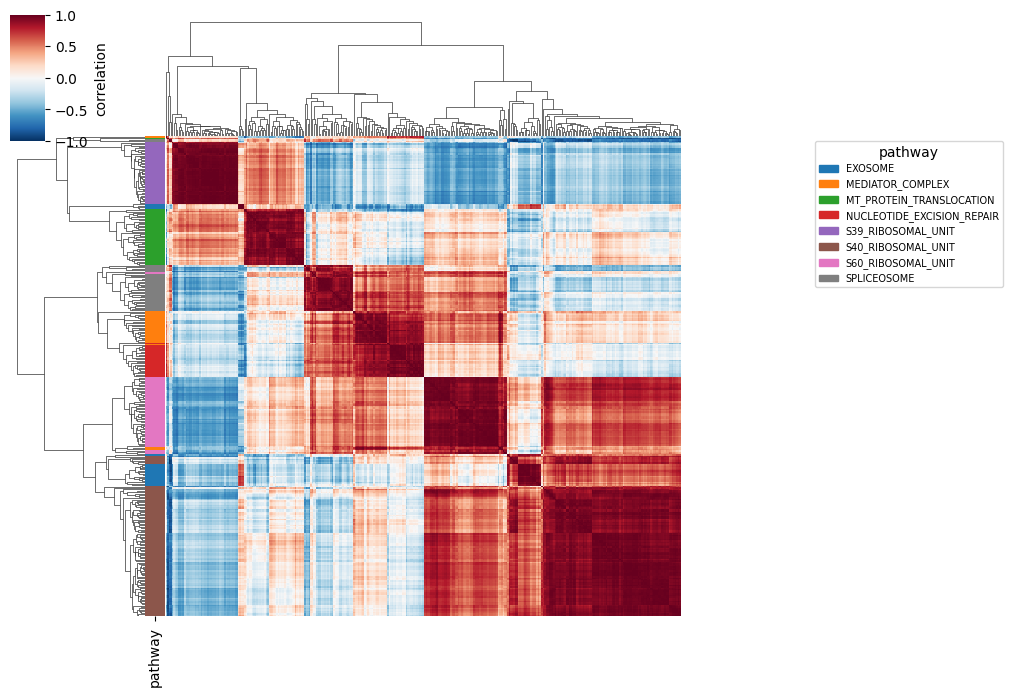

In [11]:
rho_perts = list(res['rho_perts'])
genes_in_model = [g for g in pathway_genes if g in rho_perts]
ix = [rho_perts.index(g) for g in genes_in_model]
rho_sub = pd.DataFrame(np.asarray(res['rho_corr'])[np.ix_(ix, ix)],
                       index=genes_in_model, columns=genes_in_model)

pw_names = sorted(pathways)
pw_colors = dict(zip(pw_names, sns.color_palette('tab10', len(pw_names))))
row_colors = pd.Series([pw_colors[gene_to_pathway[g]] for g in genes_in_model],
                       index=genes_in_model, name='pathway')

g = sns.clustermap(rho_sub, cmap='RdBu_r', vmin=-1, vmax=1, method='average',
                   row_colors=row_colors, xticklabels=False, yticklabels=False,
                   figsize=(7, 7), cbar_kws={'label': 'correlation'})
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in pw_colors.values()]
g.ax_heatmap.legend(handles, pw_colors.keys(), bbox_to_anchor=(1.25, 1), loc='upper left',
                    fontsize=7, title='pathway')
plt.show()

The learned correlations (`rho_corr`) should agree with the correlations of per-perturbation
mean latent states (`z_corr`). A large disagreement would mean the covariance prior and the
fitted cell states tell different stories.

Agreement of rho_corr and z_corr:  Spearman = 0.752   Pearson = 0.756


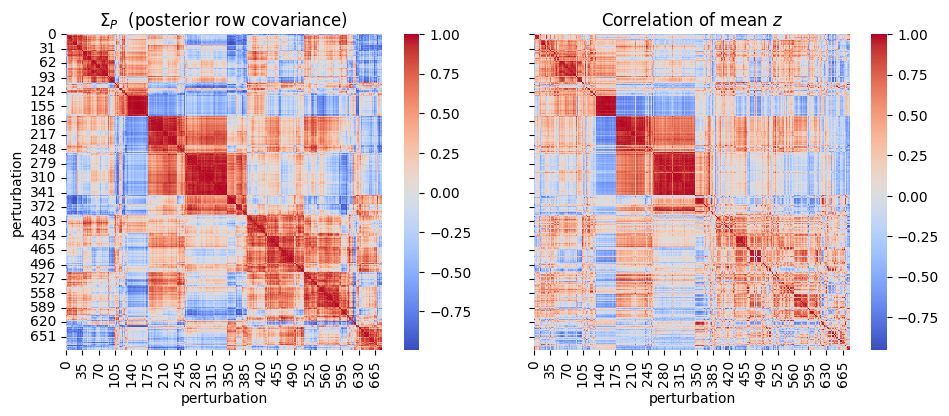

In [12]:
zrc = res['z_rho_corr']
print(f"Agreement of rho_corr and z_corr:  Spearman = {zrc['spearman_r']:.3f}   "
      f"Pearson = {zrc['pearson_r']:.3f}")
slk.pl.plot_zcorr(data)

### Grouping perturbations and comparing with pathways

We cluster the pathway genes into 8 groups by hierarchical clustering on the correlation matrix,
using the same procedure as the benchmark. `slk.tl.compute_clustering_metrics` scores the groups
against the annotations (F1, ARI, AMI and silhouette: the clustering columns of Fig. 1g).

In [13]:
N_GROUPS = len(pathways)

metrics = slk.tl.compute_clustering_metrics(
    data, pathway_df, pathway_genes, n_clusters=N_GROUPS, use_rho=False,
)
pd.Series({k: metrics[k] for k in
           ['cluster_f1', 'cluster_ari', 'cluster_ami', 'cluster_silhouette']}).round(3).to_frame('score')

,score
cluster_f1,0.997
cluster_ari,0.994
cluster_ami,0.992
cluster_silhouette,0.433


To label each inferred group, we match groups to pathways one-to-one with the Hungarian
algorithm. Each perturbation then receives a "mapped pathway", which is the model's inferred
grouping.

In [14]:
z_perts = list(res['z_perts'])
genes = [g for g in pathway_genes if g in z_perts]
ix = [z_perts.index(g) for g in genes]
C = np.asarray(res['z_corr'])[np.ix_(ix, ix)]

groups = slk.tl.cluster_rho(data, t=N_GROUPS, rho_corr=C, criterion='maxclust', show=False)
groups_df = pd.DataFrame({'group': groups.astype(str),
                          'pathway': [gene_to_pathway[g] for g in genes]}, index=genes)

contingency = pd.crosstab(groups_df['pathway'], groups_df['group'])
rows, cols = linear_sum_assignment(-contingency.values)
group_to_pathway = {contingency.columns[c]: contingency.index[r] for r, c in zip(rows, cols)}
groups_df['mapped_pathway'] = groups_df['group'].map(group_to_pathway)

print(f"Perturbations whose inferred group matches their pathway: "
      f"{(groups_df['mapped_pathway'] == groups_df['pathway']).mean():.1%}")
contingency.rename(columns=group_to_pathway)

Perturbations whose inferred group matches their pathway: 99.7%


group,S39_RIBOSOMAL_UNIT,MT_PROTEIN_TRANSLOCATION,SPLICEOSOME,NUCLEOTIDE_EXCISION_REPAIR,MEDIATOR_COMPLEX,EXOSOME,S40_RIBOSOMAL_UNIT,S60_RIBOSOMAL_UNIT
pathway,,,,,,,,
EXOSOME,0,0,0,0,0,20,0,0
MEDIATOR_COMPLEX,0,0,0,0,26,0,0,0
MT_PROTEIN_TRANSLOCATION,0,40,0,0,0,0,0,0
NUCLEOTIDE_EXCISION_REPAIR,0,0,0,23,0,0,0,0
S39_RIBOSOMAL_UNIT,43,0,0,0,0,0,0,0
S40_RIBOSOMAL_UNIT,0,0,0,0,0,0,97,0
S60_RIBOSOMAL_UNIT,0,0,0,0,0,0,0,53
SPLICEOSOME,0,0,32,0,0,0,0,1


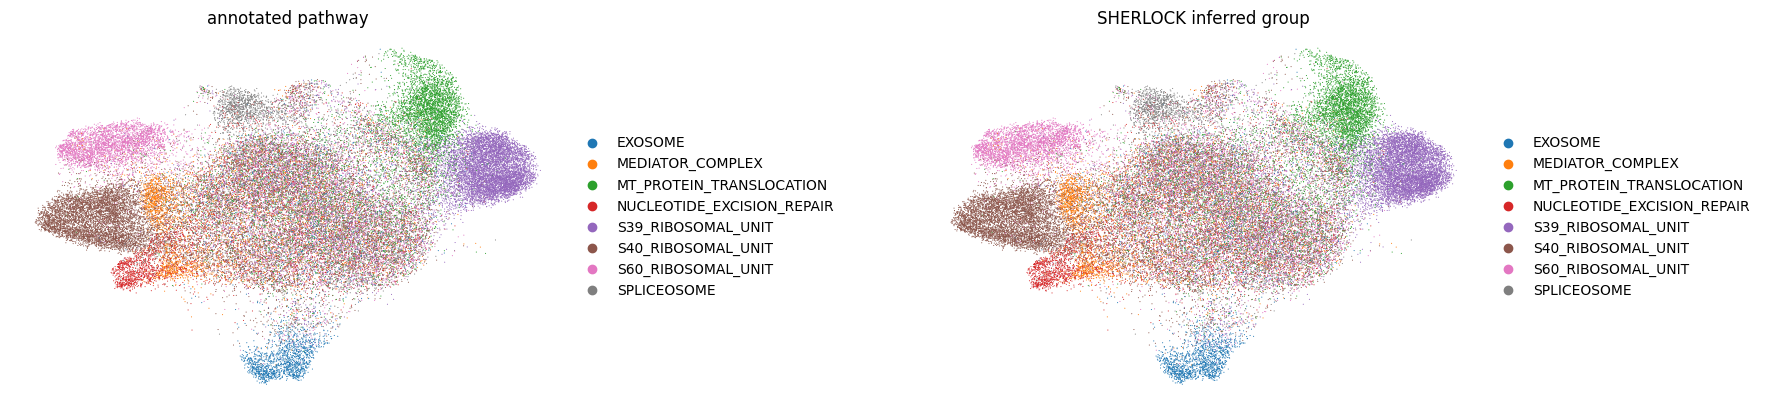

In [15]:
sub_pw = sub[sub.obs[P_KEY].isin(genes)].copy()
sub_pw.obs['mapped_pathway'] = pd.Categorical(sub_pw.obs[P_KEY].map(groups_df['mapped_pathway']),
                                              categories=pw_names)
sub_pw.obs['pathway'] = pd.Categorical(sub_pw.obs['pathway'].astype(str), categories=pw_names)
palette = [pw_colors[p] for p in pw_names]
sc.pl.umap(sub_pw, color=['pathway', 'mapped_pathway'], palette=palette, frameon=False, wspace=0.5,
           title=['annotated pathway', 'SHERLOCK inferred group'])

## 7. Sparse gates

$W$ (perturbations × latent factors) controls which latent factors each perturbation may shift.
Most entries should be near 0 or 1: each perturbation acts through a small, specific set of
factors. This sparsity is what makes the representation modular and interpretable.

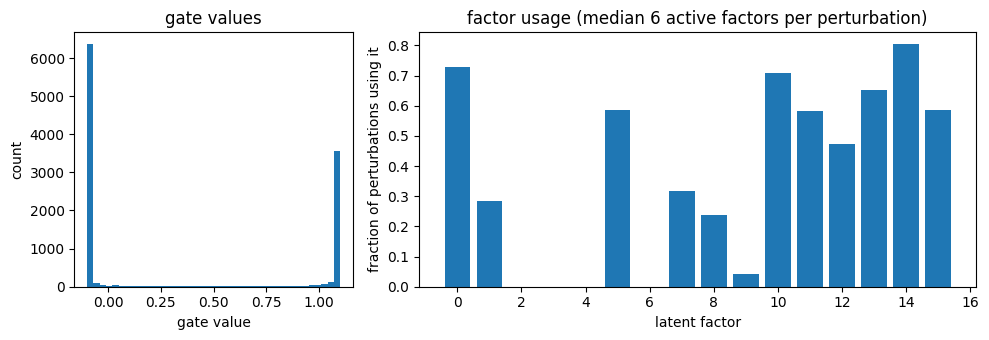

In [16]:
W = np.asarray(res['W'])
W = W.reshape(-1, W.shape[-1])
active = W > 0.5

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), gridspec_kw={'width_ratios': [1, 2]})
axes[0].hist(W.ravel(), bins=40)
axes[0].set(xlabel='gate value', ylabel='count', title='gate values')
axes[1].bar(np.arange(W.shape[1]), active.mean(0))
axes[1].set(xlabel='latent factor', ylabel='fraction of perturbations using it',
            title=f'factor usage (median {np.median(active.sum(1)):.0f} active factors per perturbation)')
plt.tight_layout()
plt.show()

## 8. Downstream effects of each perturbation

`counterfactual_effect_size` measures how strongly each perturbation's latent shift changes each
gene once decoded. `slk.tl.ev_sig` tests, for every perturbation, which genes are affected
unusually strongly relative to that perturbation's other genes, and stores p- and q-values.
`make_ev_long_df` returns the result as a tidy table.

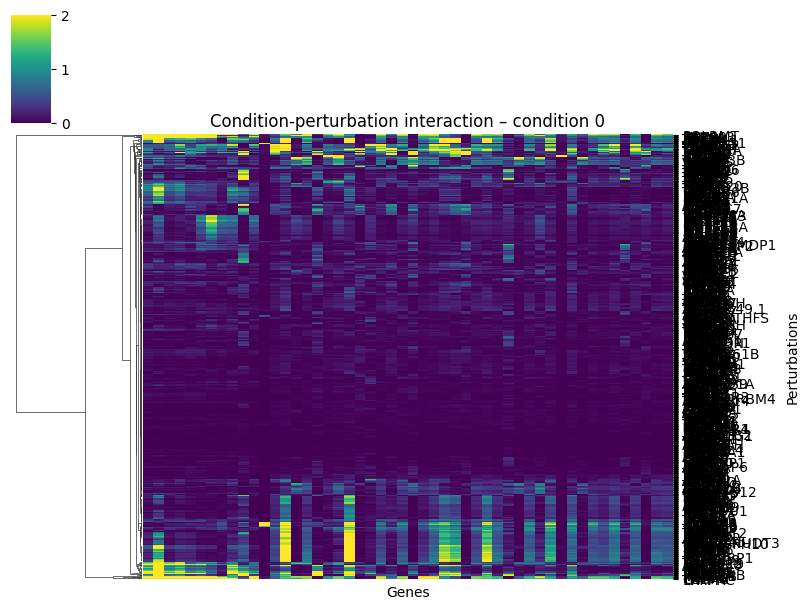

In [17]:
slk.pl.plot_ev(data, cmax=2, top_n=50)

In [18]:
slk.tl.ev_sig(data, fdr_alpha=0.05)
ev_df = slk.pl.make_ev_long_df(data)
print(f"Significant perturbation -> gene pairs (q < 0.05): {(ev_df['qval'] < 0.05).sum():,}")
ev_df.sort_values('qval').head()

Significant perturbation -> gene pairs (q < 0.05): 131,249


,pert,gene,ev,pval,qval
265436,INTS1,MT-ND4,0.041804,1.000000e-300,7.953020e-300
264664,INTS1,AIF1,0.012635,1.000000e-300,7.953020e-300
264668,INTS1,SNHG32,0.004005,1.000000e-300,7.953020e-300
264674,INTS1,RPL10A,0.017949,1.000000e-300,7.953020e-300
264678,INTS1,CCND3,0.004666,1.000000e-300,7.953020e-300


Top downstream targets for two perturbations from the same complex. Perturbations that the model
groups together should share many of their targets.

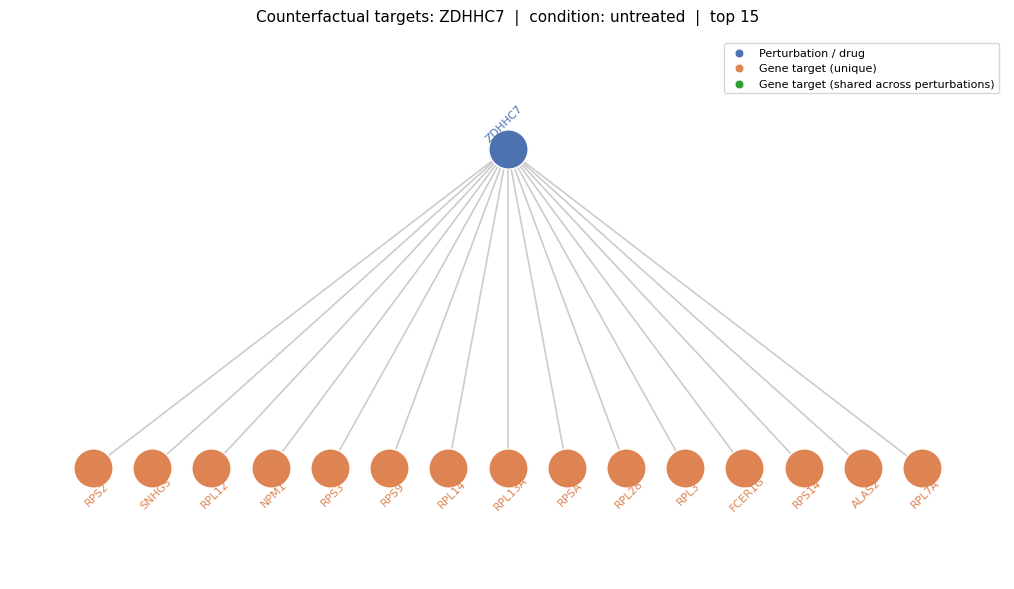

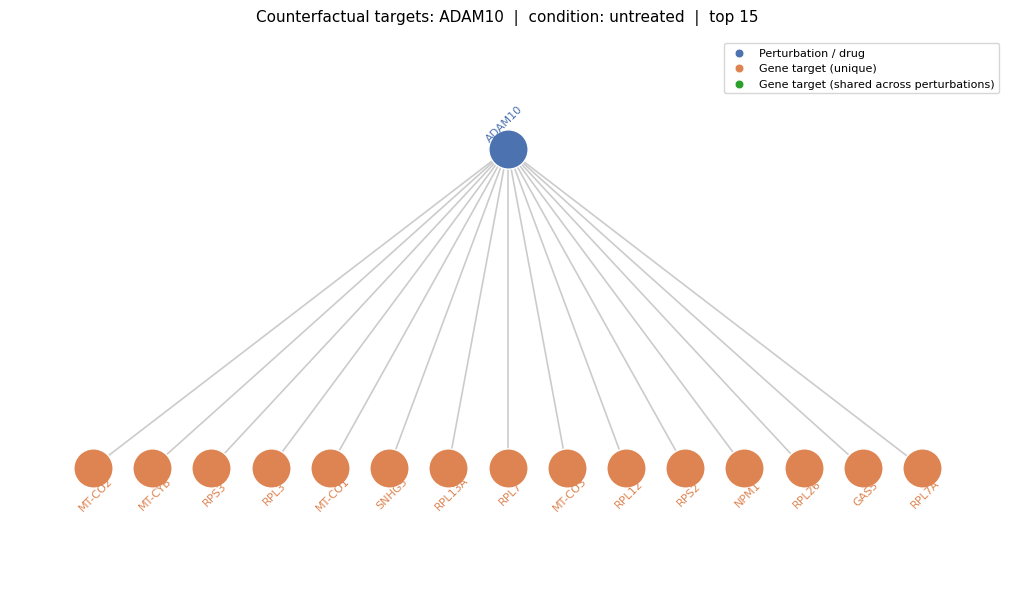

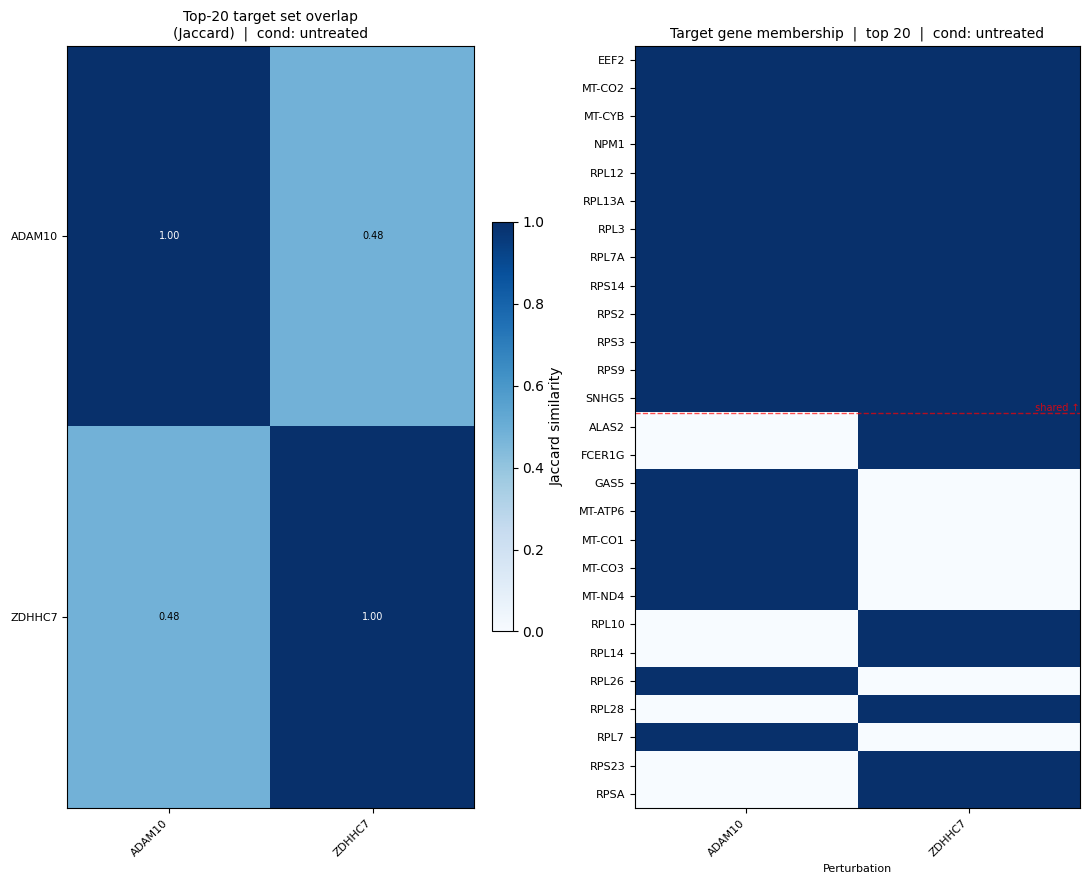

In [19]:
example = [g for g in pathways['MEDIATOR_COMPLEX'] if g in z_perts][:2]
for pert in example:
    slk.pl.plot_cf_bipartite(data, pert_name=pert, top_n=15)
slk.pl.plot_cf_target_overlap(data, pert_names=example, top_n=20)

## 9. Pathway-level enrichment of downstream targets

Finally, we collect the significant targets of every perturbation in each **inferred** group and
test them for enrichment in MSigDB Hallmark gene sets (Fig. 1f). This asks whether the groups
correspond to coherent biological programs rather than just geometric separation in latent space.

The enrichment query uses `gseapy` (included in the `tutorials` extra) and needs internet access
to Enrichr.

In [20]:
ALPHA = 0.05

sig = ev_df[(ev_df['qval'] < ALPHA) & ev_df['pert'].isin(groups_df.index)].copy()
sig['group'] = sig['pert'].map(groups_df['mapped_pathway'])
group_targets = (
    sig.groupby(['group', 'gene'])
       .agg(n_perts=('pert', 'nunique'), mean_ev=('ev', 'mean'))
       .reset_index()
       .sort_values(['group', 'mean_ev'], ascending=[True, False])
)
group_targets.groupby('group').size().rename('n_significant_targets').to_frame()

,n_significant_targets
group,
EXOSOME,678
MEDIATOR_COMPLEX,489
MT_PROTEIN_TRANSLOCATION,561
NUCLEOTIDE_EXCISION_REPAIR,428
S39_RIBOSOMAL_UNIT,269
S40_RIBOSOMAL_UNIT,329
S60_RIBOSOMAL_UNIT,485
SPLICEOSOME,701


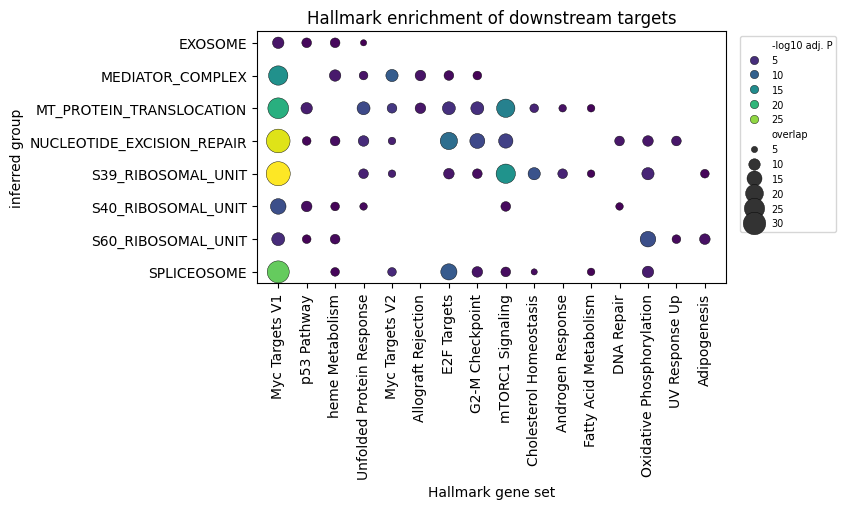

In [21]:
import time

try:
    import gseapy as gp
except ImportError:
    gp = None
    print("gseapy is not installed; skipping enrichment (pip install 'sherlock-perturb[tutorials]').")

if gp is not None:
    rows = []
    for group, df in group_targets.groupby('group'):
        gene_list = df['gene'].astype(str).head(200).tolist()
        if len(gene_list) < 5:
            continue
        time.sleep(2)   # stay under Enrichr's request-rate limit
        enr = gp.enrichr(gene_list=gene_list, gene_sets=['MSigDB_Hallmark_2020'],
                         organism='human', outdir=None, cutoff=1.0).results
        enr = enr[enr['Adjusted P-value'] <= ALPHA].nsmallest(20, 'Adjusted P-value')
        enr['group'] = group
        enr['overlap'] = enr['Overlap'].str.split('/').str[0].astype(int)
        rows.append(enr)
    enrich = pd.concat(rows, ignore_index=True)
    enrich["-log10 adj. P"] = -np.log10(enrich["Adjusted P-value"])

    fig, ax = plt.subplots(figsize=(0.35 * enrich['Term'].nunique() + 3,
                                    0.4 * enrich['group'].nunique() + 2))
    sns.scatterplot(data=enrich, x='Term', y='group', size='overlap', sizes=(20, 300),
                    hue='-log10 adj. P', palette='viridis',
                    edgecolor='k', linewidth=0.3, ax=ax)
    ax.tick_params(axis='x', rotation=90)
    ax.set(xlabel='Hallmark gene set', ylabel='inferred group',
           title='Hallmark enrichment of downstream targets')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    plt.tight_layout()
    plt.show()

## Next steps

- **Perturbations measured under several conditions:** the [conditional-perturbation tutorial](conditional_perturbations.ipynb) models drug
  responses with and without T-cell co-culture.
- **Combinations of perturbations and genetic interactions:**
  the [combinatorial-perturbation tutorial](combinatorial_perturbations.ipynb).
- **Benchmarking against cVAE, sVAE+, contrastiveVI and scGen, and every manuscript figure:**
  [SHERLOCK_Reproducibility](https://github.com/azizilab/SHERLOCK_Reproducibility).

## References

1. Zhang M, Myers JD, Shi L, Giglio RM, Chatterjee S, McFaline-Figueroa JL, Azizi E. SHERLOCK: Structured representation learning and causal inference of downstream perturbation effects. *bioRxiv* (2026). [doi:10.64898/2026.09.25.754573](https://www.biorxiv.org/content/10.64898/2026.09.25.754573v1)
2. Replogle JM *et al.* Mapping information-rich genotype-phenotype landscapes with genome-scale Perturb-seq. *Cell* **185**, 2559–2575 (2022). [doi:10.1016/j.cell.2022.05.013](https://doi.org/10.1016/j.cell.2022.05.013)
3. Liberzon A *et al.* The Molecular Signatures Database (MSigDB) hallmark gene set collection. *Cell Systems* **1**, 417–425 (2015). [doi:10.1016/j.cels.2015.12.004](https://doi.org/10.1016/j.cels.2015.12.004)